In [1]:
import pandas as pd
import numpy as np
import scipy.special
import matplotlib.pyplot as plt

1. The beforehand glimpse (don't get confused)

In [38]:
def avg(x,y):
    print("1st input:", x)
    print("2nd input:", y)
    a = (x+y)/2.0 # using 2.0 instead of 2 to avoid round down
    return a

In [39]:
avg(4,7)

1st input: 4
2nd input: 7


5.5

In [40]:
class Dog:
    # initialisation method with internal data
    def __init__(self, petname, temp) :
        self.name = petname,
        self.temperature = temp,

    def status(self):
        print("dog name is ", self.name)
        print("dog temperature is ", self.temperature)
        pass

    def setTemperature(self,temp) :
        self.temperature = temp,
        pass
    
    def bark(self) :
        print("woof!")
        pass
    pass
    

In [41]:
lassie = Dog("Lassie", 37)
lassie.status()

dog name is  ('Lassie',)
dog temperature is  (37,)


## --------- NEURAL NETWORK ------------- 

The Skeleton Code

● initialisation to
set the number of input, hidden and output nodes
● train refine
the weights after being given a training set example to learn from
● query give
an answer from the output nodes after being given an input

In [42]:
# neural network class definition
class neuralNetwork :
    # initialise the neural network
    def _init__() :
        pass
    # train the neural network
    def train() :
        pass
    # query the neural network
    def query() :
        pass

# THIS IS CLASSIFICATION PROBLEM

# ---- NN 1 hidden layer --------

1. Architechture establishment

In [19]:
class NeuralNetwork:
    # initialise the neural network
    def __init__(self, inputnodes, hiddennodes, outputnodes, learningrate):
        # set number of nodes in each input, hidden, output layer
        self.inodes = inputnodes
        self.hnodes = hiddennodes
        self.onodes = outputnodes


## THE MOST IMPORTANT PART (LINK WEIGHTS)
        # link weight matrices, wih and who
        # wih: weights from input -> hidden (shape: hnodes x inodes)
        # who: weights from hidden -> output (shape: onodes x hnodes)
        self.wih = np.random.normal(
            0.0, pow(self.hnodes, -0.5), (self.hnodes, self.inodes)
        )
        self.who = np.random.normal(
            0.0, pow(self.onodes, -0.5), (self.onodes, self.hnodes)
        )

        # learning rate
        self.lr = learningrate

        # activation function is the sigmoid function
        self.activation_function = lambda x: scipy.special.expit(x)
        pass

    # train the neural network (placeholder)
    def train(self, inputs_list, targets_list):
        # convert inputs list to 2d array
        inputs = np.array(inputs_list, ndmin=2).T
        targets = np.array(targets_list, ndmin=2).T

        # calculate signals into hidden layer
        hidden_inputs = np.dot(self.wih, inputs)
        # calculate the signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)

        # calculate signals into final output layer
        final_inputs = np.dot(self.who, hidden_outputs)
        # calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)
        
        # output layer error is the (actual - predicted)
        output_errors = targets - final_outputs
        # hidden layer error is the output_errors, split by weights,recombined at hidden nodes
        hidden_errors=np.dot(self.who.T, output_errors)
        
        # update the weights for the links between the hidden and output layers
        self.who += self.lr * np.dot(
            (output_errors * final_outputs * (1.0 - final_outputs)), 
            np.transpose(hidden_outputs)
            )
        # update the weights for the links between the input and hidden layers
        self.wih += self.lr * np.dot(
            (hidden_errors * hidden_outputs * (1.0 - hidden_outputs)), 
            np.transpose(inputs)
            )
        pass


    # query the neural network
    def query(self, inputs_list):
        # convert inputs list to 2d array (column vector)
        inputs = np.array(inputs_list, ndmin=2).T

        # calculate signals into hidden layer
        hidden_inputs = np.dot(self.wih, inputs)
        # calculate the signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)

        # calculate signals into final output layer
        final_inputs = np.dot(self.who, hidden_outputs)
        # calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)

        return final_outputs


2. Number of input, hidden and output nodes

In [20]:
# number of input, hidden and output nodes
input_nodes= 784
hidden_nodes= 200
output_nodes= 10

# learning rate
learning_rate=0.1

# create instance of neural network
n=NeuralNetwork(input_nodes, hidden_nodes, output_nodes, learning_rate)

The most important part of the network is the link weights. The initial values of the link weights should be small and random

## The MNIST Dataset - using 100

3. Load the Dataset

In [21]:
# Load the mnist training data CSV file into a list

training_data_file = open(r"C:\Users\serly\Documents\Bioinformatics\Learning\Jupyter\mnist_train_100.csv", "r")
# r tells Python to open the file for reading only not writing
training_data_list = training_data_file.readlines()
# readlines = read all of the lines in the file into the variable data_list
training_data_file.close()

In [22]:
len(training_data_list)

100

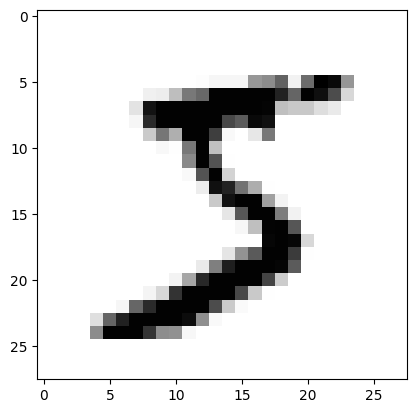

In [23]:
all_values = training_data_list[0].split(",")

image_array = np.asarray(all_values[1:], dtype=float).reshape(28, 28)

plt.imshow(image_array, cmap="Greys", interpolation="None")
plt.show()


In [24]:
scaled_input = (np.asarray(all_values[1:],dtype=float)/255.0 * 0.99) + 0.01
print(scaled_input)

[0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0.01       0.01       0.01       0.01
 0.01       0.01       0

In [25]:
onodes = 10
targets = np.zeros(onodes) + 0.01
targets[int(all_values[0])] = 0.99
print(targets)

[0.01 0.01 0.01 0.01 0.01 0.99 0.01 0.01 0.01 0.01]


The idea is that neural networks should find features or patterns in the input which can
be expressed in a shorter form than the input itself.

4. Train the neural network

In [26]:
# epochs is the number of times the training data set is used 
# for training
epochs = 5

for e in range(epochs):
    for record in training_data_list:
        all_values= record.split(",")
        inputs= (np.asarray(all_values[1:], dtype=float)/255.0 * 0.99) + 0.01
        targets = np.zeros(output_nodes) + 0.01
        targets[int(all_values[0])] = 0.99
        n.train(inputs, targets)
        pass
    pass

5. Load Mnist test data CSV

In [28]:
test_data_file= open(r"C:\Users\serly\Documents\Bioinformatics\Learning\Jupyter\mnist_test_10.csv", 'r')
test_data_list = test_data_file.readlines()
test_data_file.close()

In [29]:
all_values = test_data_list[0]. split(',')
print(all_values[0])

7


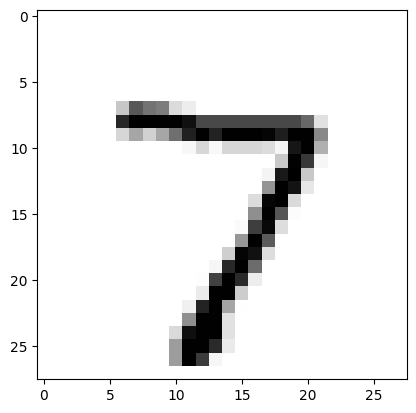

In [30]:
image_array1 = np.asarray(all_values[1:], dtype=float).reshape(28, 28)

plt.imshow(image_array1, cmap="Greys", interpolation="None")
plt.show()

6. Test the neural network

In [31]:
scorecard = [] 

for record in test_data_list:
    all_values= record.split(',')
    correct_label=int(all_values[0])
    inputs= (np.asarray(all_values[1:], dtype=float)/255.0 * 0.99) + 0.01

    outputs = n.query(inputs)
    label = np.argmax(outputs)

    if (label == correct_label):
        scorecard.append(1)
else:
    scorecard.append(0)
    pass
pass

7. Evaluate the performance

In [32]:
# calculate the performance score, the fraction of correct answers
scorecard_array = np.asarray(scorecard)
print ("performance = ", scorecard_array.sum() / scorecard_array.size)

performance =  0.8571428571428571


# ========== ALL FULL 60k DATASET (Both Train and Test) ================

## ------- 1 layer --------

In [33]:
train_file60 = open(r"C:\Users\serly\Documents\Bioinformatics\Learning\Jupyter\mnist_train.csv")
train_list60= train_file60.readlines()
train_file60.close()

In [34]:
len(train_list60)

60000

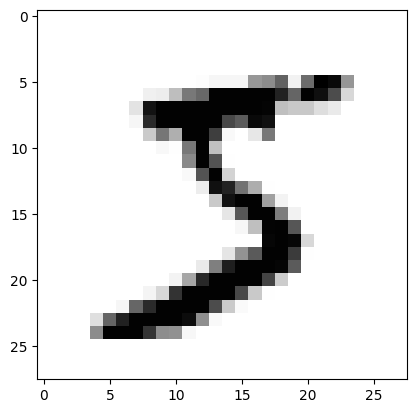

In [35]:
# So, basically from the dataset, the first number is the real/actual/correct answer [0],
# and the rest after that number [1:] are the handwritting
all_values60 = train_list60[0].split(",")

image_array = np.asarray(all_values60[1:], dtype=float).reshape(28, 28)

plt.imshow(image_array, cmap="Greys", interpolation="None")
plt.show()

In [36]:
# Initialisation

class NeuralNetwork60:
    def __init__(self, inputnodes, hiddennodes, outputnodes, learningrate60):
        self.inodes60 = inputnodes
        self.hnodes60= hiddennodes
        self.onodes60 = outputnodes
    

        # linking the weights matrices, Wih, Who
        self.wih60 = np.random.normal(0.0, pow(self.hnodes60, -0.5), (self.hnodes60, self.inodes60))
        self.who60 = np.random.normal(0.0, pow(self.onodes60, -0.5), (self.onodes60, self.hnodes60))
        # taking random number using the numpy library

        # setting up the learning rate
        self.lr60 = learningrate60

        #activation function (sigmoid)
        self.activationfunction60 = lambda x: scipy.special.expit(x)
        pass


# TRAINING

    def train60(self, inputs60_list, targets60_list):
        inputs60 = np.array(inputs60_list, ndmin=2).T
        targets60 = np.array(targets60_list, ndmin=2).T

        # FEED FORWARD (INPUT LAYER - HIDDEN LAYER)
        # calculate signals into hidden layer (feed forward)
        hidden_input60 = np.dot(self.wih60, inputs60)
        # calculate the signals emerging FROM the hidden layer
        hidden_output60 = self.activationfunction60(hidden_input60)

        # FEED FORWARD (HIDEEN LAYER - OUTPUT/FINAL LAYER)
        # calculate signals into output layer
        output_input60 = np.dot(self.who60, hidden_output60)
        # calculate the signals emerging FROM the hidden layer
        output_output60 = self.activationfunction60(output_input60)


        # THE ERROR (targets60 -output_output60) basically (target/actual - predicted)
        output_errors60 = targets60 - output_output60
        # hidden layer error is the output_errors60, split by weights,recombined at hidden nodes
        hidden_errors60 =np.dot(self.who60.T, output_errors60)

        # UPDATED WEIGHTS AFTER RECOMBINE WITH THE LEARNING RATE
        # BACK PROPAGATING and GRADIENT DESCENT to update the step by step weights
        self.who60 += self.lr60 * np.dot(
            (output_errors60 * output_output60 * (1.0 - output_output60)), np.transpose(hidden_output60)
        )
        self.wih60 += self.lr60 * np.dot(
            (hidden_errors60 * hidden_output60 * (1.0 - hidden_output60)), np.transpose(inputs60)
        )
        pass

# QUERY 
    def query60 (self, inputs60_list):
        
        inputs60 = np.array(inputs60_list, ndmin=2).T
        # calculate signals into hidden layer
        hidden_input60 = np.dot(self.wih60, inputs60)
        # calculate the signals emerging FROM the hidden layer
        hidden_output60 = self.activationfunction60(hidden_input60)

        # FEED FORWARD (HIDEEN LAYER - OUTPUT/FINAL LAYER)
        # calculate signals into output layer
        output_input60 = np.dot(self.who60, hidden_output60)
        # calculate the signals emerging FROM the hidden layer
        output_output60 = self.activationfunction60(output_input60)

        return output_output60


NOW INPUT THE PARAMETERS and TRAIN THE TRAIN DATA

In [37]:
# SET UP THE NUMBER OF NODES AND WEIGHTS
# We are using 3 layers only (input, hidden, output)

inputnodes= 784
hiddennodes= 200
outputnodes= 10 # (0,1,2,3,4,5,6,7,8,9)

# learning rate
learningrate60=0.1

# create instance of neural network
n=NeuralNetwork60(inputnodes, hiddennodes, outputnodes, learningrate60)

In [38]:
# This is to scale the output nodes from range 0.01 - 0.99, so no training result in 0
# and you can see the big value 0.99 is in position 5 for the list 0 which is the actual answer is 5
# if you change the all_value60[1], you will get 0
# if you forget, see again the dataset
scaled_input60 = (np.asarray(all_values60[1:], dtype=float)/255.0 * 0.99) + 0.01
outputnodes = 10
targets60 = np.zeros(outputnodes)+0.01
targets60[int(all_values60[0])] = 0.99
print(targets60)


[0.01 0.01 0.01 0.01 0.01 0.99 0.01 0.01 0.01 0.01]


Time to train the model on train dataset 60k

In [39]:
epochs60 = 5

for e in range (epochs60):
    for record in train_list60:
        all_values60 = record.split(",")
        scaled_input60 =(np.asarray(all_values60[1:], dtype=float)/255.0 * 0.99) + 0.01
        targets60 = np.zeros(outputnodes)+0.01
        targets60[int(all_values60[0])] = 0.99
        n.train60(scaled_input60, targets60) #like predict x,y
        pass
    pass

NOW CHECK ON UNSEEN DATA AFTER TRAINING

In [40]:
test_file60= open(r"C:\Users\serly\Documents\Bioinformatics\Learning\Jupyter\mnist_test.csv")
test_list60 = test_file60.readlines()
test_file60.close()

In [41]:
# Test on test data

scorecard_test = []

for record in test_list60:
    all_values60 = record.split(",")
    correct_answer= int(all_values60[0])
    scaled_input60= (np.asarray(all_values60[1:], dtype=float)/255.0*0.99) + 0.01

    outputs60 = n.query60(scaled_input60) #basically to predict
    predicted_answer = np.argmax(outputs60)

    if (predicted_answer == correct_answer):
        scorecard_test.append(1)
    else:
        scorecard_test.append(0)
        pass
    pass

In [42]:
# Test performance score:

scorecard_test_array = np.asarray(scorecard_test)
print("Performance:", scorecard_test_array.sum()/scorecard_test_array.size)

Performance: 0.9732


# ------ 2 hidden layers --------------

In [10]:
class NN2:
    def __init__(self, inputnodes,hiddennodes1, hiddennodes2, outputnodes, learningrate2):
        self.inodes = inputnodes
        self.hnodes1 = hiddennodes1
        self.hnodes2 = hiddennodes2
        self.onodes = outputnodes
        

         # input -> hidden layer1
        self.wih1 = np.random.normal(0.0, pow (self.hnodes1, -0.5), (self.hnodes1, self.inodes))
        self.wh1h2 = np.random.normal(0.0, pow(self.hnodes2, -0.5), (self.hnodes2, self.hnodes1))
        self.wh2o = np.random.normal(0.0, pow(self.onodes, -0.5), (self.onodes, self.hnodes2))
        pass

        # learning rate
        self.lr2= learningrate2

        # activation function: sigmoid
        self.activationfunction2= lambda x: scipy.special.expit(x)
        # x represents a real-valued numerical input, typically a NumPy array (ndarray) or a scalar, 
        # passed into the logistic sigmoid function

# TRAINING

    # 1. CALCULATING THE SIGNAL IN EACH LAYER FROM WEIGHTS COMBINED
    def train2(self, inputs60_list, targets60_list):
        # input = 784
        # output/target = 10 (0,1,2,3,4,5,6,7,8,9)
        inputs60 = np.array(inputs60_list, ndmin=2).T #???
        targets60 = np.array(targets60_list, ndmin=2).T #???

        # FEED FORWARD (INPUT LAYER - HIDDEN LAYER 1)
        # calculate signals into hidden layer 1 (feed forward)
        hidden1_input = np.dot(self.wih1, inputs60)
        hidden1_output = self.activationfunction2(hidden1_input)

        hidden2_input = np.dot(self.wh1h2, hidden1_output)
        hidden2_output = self.activationfunction2(hidden2_input)

        output1_input = np.dot(self.wh2o, hidden2_output)
        output1_output = self.activationfunction2(output1_input)

    # 2. BACKPROPAGATING THE ERROR (BECAUSE WE DONT KNOW THE ERROR IN HIDDEN LAYER,
    # THAT'S WHY WE USE REFERENCE FROM OUTPUT --> back to forward to calculate and readjust
    # the errors)
        # Error = target60 - output1_output
        output1_error = targets60 - output1_output

        # hidden layer 2 error is the output1_errors, split by weights,recombined at hidden nodes 
        hidden2_oh2_error = np.dot(self.wh2o.T, output1_error)
        hidden1_h2h1_error = np.dot(self.wh1h2.T, hidden2_oh2_error)
        

        self.wh2o += self.lr2 * np.dot(
            (output1_error * output1_output * (1.0 - output1_output)),
            np.transpose(hidden2_output)
            )
        
        self.wh1h2 += self.lr2 * np.dot(
            (hidden2_oh2_error * hidden2_output * (1.0 - hidden2_output)),
            np.transpose(hidden1_output)
            )
        
        self.wih1 += self.lr2 * np.dot(
            (hidden1_h2h1_error * hidden1_output *(1.0 -hidden1_output)),
            np.transpose(inputs60)
            )
        pass



    # QUERY
    def query2 (self, inputs60_list):
        inputs60 = np.array(inputs60_list, ndmin=2).T

        hidden1_input = np.dot(self.wih1, inputs60)
        hidden1_output = self.activationfunction2(hidden1_input)

        hidden2_input = np.dot(self.wh1h2, hidden1_output)
        hidden2_output = self.activationfunction2(hidden2_input)

        output1_input = np.dot(self.wh2o, hidden2_output)
        output1_output = self.activationfunction2(output1_input)

        return output1_output




In [11]:
# PARAMETERS

inputnodes = 784
hiddennodes1 = 100
hiddennodes2 = 100
outputnodes = 10

learningrate2 = 0.1

n2 = NN2(inputnodes,hiddennodes1, hiddennodes2, outputnodes, learningrate2)

In [12]:
scaled_input60 = (np.asarray(all_values60[1:], dtype=float)/255.0 * 0.99) + 0.01
outputnodes = 10
targets60 = np.zeros(outputnodes)+0.01
targets60[int(all_values60[0])] = 0.99
print(targets60)

[0.01 0.01 0.01 0.01 0.01 0.99 0.01 0.01 0.01 0.01]


In [15]:
# TRAIN THE n2 NN MODEL

epochs60 = 5
# -------- TRAINING LOOP ---------------
for e in range (epochs60):
    for record in train_list60:
        all_values60 = record.split(",")
        scaled_input60 =(np.asarray(all_values60[1:], dtype=float)/255.0 * 0.99) + 0.01
        targets60 = np.zeros(outputnodes)+0.01
        targets60[int(all_values60[0])] = 0.99

        
        n2.train2(scaled_input60, targets60) #like predict x,y
        


# --------- PERFORMANCE AFTER EACH EPOCH ----------
# TRAIN DATA
    train_scorecard = []

    for record in train_list60:
        all_values60 = record.split(",")
        correct_answer = int(all_values60[0])
        scaled_input60 = (np.asarray(all_values60[1:], dtype=float)/255.0*0.99) + 0.01

        outputs_n2_test = n2.query2(scaled_input60) #basically to predict
        predicted_answer_n2 = np.argmax(outputs_n2_test)

        if (predicted_answer_n2 == correct_answer):
            train_scorecard.append(1)
        else:
            train_scorecard.append(0)
    
# TEST DATA
    test_scorecard = []

    for record in test_list60:
        all_values60 = record.split(",")
        correct_answer = int(all_values60[0])
        scaled_input60 = (np.asarray(all_values60[1:], dtype=float)/255.0*0.99) + 0.01

        outputs_n2_test = n2.query2(scaled_input60) #basically to predict
        predicted_answer_n2 = np.argmax(outputs_n2_test)

        if (predicted_answer_n2 == correct_answer):
            test_scorecard.append(1)
        else:
            test_scorecard.append(0)
    

    train_accuracy = np.array (train_scorecard).sum()/len(train_scorecard) *100
    test_accuracy = np.array(test_scorecard).sum()/len(test_scorecard)*100

    print(f"Epoch {e+1}/{epochs60} | Train accuracy:{train_accuracy:.2f}% | Test accuracy: {test_accuracy:.2F}%")



Epoch 1/5 | Train accuracy:90.68% | Test accuracy: 90.91%
Epoch 2/5 | Train accuracy:91.23% | Test accuracy: 91.32%
Epoch 3/5 | Train accuracy:91.40% | Test accuracy: 91.06%
Epoch 4/5 | Train accuracy:92.84% | Test accuracy: 92.97%
Epoch 5/5 | Train accuracy:91.28% | Test accuracy: 91.62%


# Save the MLP NN Model

In [45]:
# Save 2 hidden layers model - n2

np.savez("n_model.npz",
         wih1=n2.wih1,
         wh1h2=n2.wh1h2,
         wh2o=n2.wh2o)

print("Model Saved")

Model Saved


In [46]:
# Save 1 hidden layer model - n

np.savez("n2_model.npz",
         wih60=n.wih60,
         who60=n.who60)

print("Model Saved")

Model Saved
